# Fraud Prediction using Random Forest

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


##  Load Cleaned Data

In [12]:
df = pd.read_csv("cleaned_fraud_dataset.csv")
print('Shape:', df.shape)
print('Fraud cases:', df['is_fraud'].sum())
print('Fraud %:', round(df['is_fraud'].mean() * 100, 2))

Shape: (200009, 20)
Fraud cases: 5992
Fraud %: 3.0


In [13]:
df.head(5)

,transaction_id,customer_id,merchant_id,transaction_type,payment_method,device_type,city,amount,old_balance,new_balance,transaction_hour,transaction_date,customer_age,is_international,failed_attempts,account_tenure_months,is_fraud,transaction_day,transaction_month,transaction_year
0,TXN0000001,CUST93810,MER2824,TRANSFER,Wallet,Android,Lucknow,1642.44,96738.51,111646.39,7,2025-05-21 07:14:08,45,0,1,4,1,Wednesday,5,2025
1,TXN0000002,CUST22280,MER4582,CASH_IN,Net Banking,iPhone,Ahmedabad,593.59,6872.91,6279.32,0,2025-11-05 00:35:12,55,1,3,104,0,Wednesday,11,2025
2,TXN0000003,CUST10851,MER3615,PAYMENT,UPI,Android,Kolkata,12262.45,95590.49,83328.04,8,2025-06-24 08:09:13,24,1,0,109,0,Tuesday,6,2025
3,TXN0000004,CUST55082,MER5333,DEBIT,UPI,Web,Lucknow,702.38,19451.13,18748.75,17,2025-08-24 17:07:59,41,0,0,91,0,Sunday,8,2025
4,TXN0000005,CUST19116,MER1750,TRANSFER,Net Banking,Web,Ahmedabad,2603.75,46082.28,43478.53,2,2025-05-29 02:54:14,58,1,0,21,0,Thursday,5,2025


##  Feature Selection

In [14]:
drop_cols = ['transaction_id', 'customer_id', 'merchant_id', 'transaction_date']
drop_cols = [col for col in drop_cols if col in df.columns]
df = df.drop(columns=drop_cols)
df.columns.tolist()

['transaction_type',
 'payment_method',
 'device_type',
 'city',
 'amount',
 'old_balance',
 'new_balance',
 'transaction_hour',
 'customer_age',
 'is_international',
 'failed_attempts',
 'account_tenure_months',
 'is_fraud',
 'transaction_day',
 'transaction_month',
 'transaction_year']

##  Encode Categorical Columns

In [15]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Text columns found:', cat_cols)

Text columns found: ['transaction_type', 'payment_method', 'device_type', 'city', 'transaction_day']


In [16]:
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
print('Done — all columns are now numeric.')

Done — all columns are now numeric.


##  Split Features and Target

In [17]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (200009, 15)
y shape: (200009,)


##  Train Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 160007
Testing rows: 40002


##  Train Random Forest Model

In [19]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)
print('Model training complete!')

Model training complete!


##  Make Predictions

In [21]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.3).astype(int)

print('Predictions done!')
print('Fraud predicted:', y_pred.sum())

Predictions done!
Fraud predicted: 503


##  Model Evaluation


In [22]:
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

=== Classification Report ===
              precision    recall  f1-score   support

       Legit       0.98      1.00      0.99     38804
       Fraud       1.00      0.42      0.59      1198

    accuracy                           0.98     40002
   macro avg       0.99      0.71      0.79     40002
weighted avg       0.98      0.98      0.98     40002



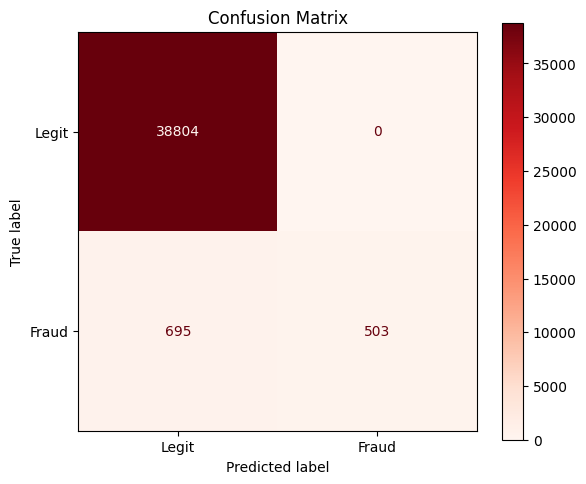


Sahi pakde gaye fraud: 503
Miss hue fraud (False Negatives): 695


In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Reds', ax=plt.gca())
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

print(f'\nSahi pakde gaye fraud: {cm[1][1]}')
print(f'Miss hue fraud (False Negatives): {cm[1][0]}')

##  Feature Importance


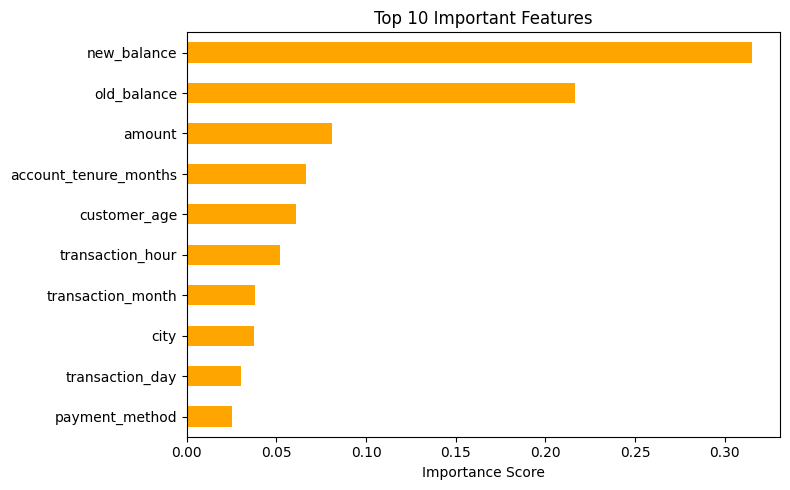

In [24]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color='orange')
plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

##  Add Risk Level
- **Low Risk** — 0 to 30% probability  
- **Medium Risk** — 30 to 70% probability  
- **High Risk** — 70%+ probability

In [25]:
results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred
results['Fraud_Probability'] = y_prob.round(3)

def risk_level(prob):
    if prob < 0.3:
        return 'Low Risk'
    elif prob < 0.7:
        return 'Medium Risk'
    else:
        return 'High Risk'

results['Risk_Level'] = results['Fraud_Probability'].apply(risk_level)

print('Risk level distribution:')
print(results['Risk_Level'].value_counts())

Risk level distribution:
Risk_Level
Low Risk       39499
Medium Risk      328
High Risk        175
Name: count, dtype: int64


##  Save Results

In [26]:
results.to_csv('fraud_prediction_results.csv', index=False)
print('Saved: fraud_prediction_results.csv')
print('Shape:', results.shape)
print('\nSample:')
results[['Actual', 'Predicted', 'Fraud_Probability', 'Risk_Level']].head(10)

Saved: fraud_prediction_results.csv
Shape: (40002, 19)

Sample:


,Actual,Predicted,Fraud_Probability,Risk_Level
11641,0,0,0.01,Low Risk
89058,0,0,0.01,Low Risk
59701,0,0,0.03,Low Risk
74880,0,0,0.02,Low Risk
44770,0,0,0.00,Low Risk
169040,0,0,0.07,Low Risk
184244,0,0,0.03,Low Risk
159353,0,0,0.01,Low Risk
14475,0,0,0.01,Low Risk
152167,0,0,0.00,Low Risk
